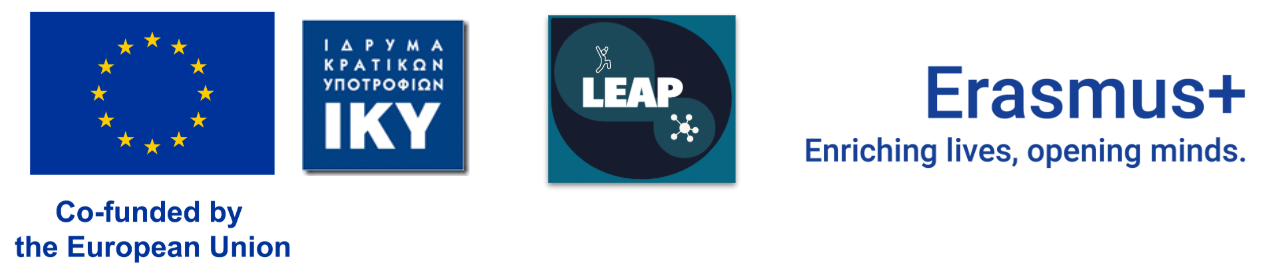

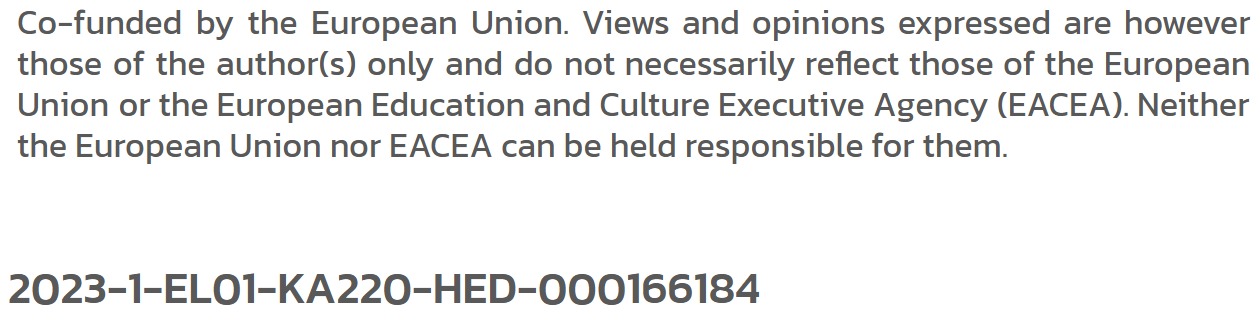

# Final Project, Option 1: Where does your CNN make its mistakes?

Software that reads handwritten numbers, such as postcodes on envelopes or account numbers on paper forms, must be judged not only on how often it is right but on where it goes wrong, because a confident misreading carries a real cost. In this project you build such a model and study the mistakes it makes.

In this project you build a convolutional neural network that recognises handwritten digits, then you study the mistakes it makes.

**Central question:** where does your CNN make its mistakes, and does one change to the model move them?

The data set is MNIST: 70,000 images of handwritten digits, each 28 by 28 pixels in greyscale, labelled 0 to 9. You download it yourself in the next cell.

This project draws on two earlier modules. In Module 5, we built and trained dense neural networks in Keras. In Module 6, we added convolutional layers, used Dropout and EarlyStopping to control overfitting, and read a confusion matrix to see which classes a model mixes up. Here you bring those skills together on a larger, more varied data set.

**How this notebook is organised.** The cells in Part A are already written for you. They handle the import, the download, and the reshaping that turns each flat row of 784 numbers back into a 28 by 28 image. From Part B onward, the cells are yours to complete. Each one carries comments describing what to do, along with a few hints, but not the finished code. Work through them in order.

Training on the full data set may take a few minutes per epoch on a laptop without a graphics card. This is expected.

## Part A. Setup and data

We start with the imports. This cell loads everything the notebook needs, so we run it once at the top.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import keras
from keras import layers

### Loading the data

We download MNIST from OpenML. The call returns the images in `X` as 70,000 rows of 784 numbers, and the labels in `y` as text. We convert the labels to integers so the model can work with them. The download runs once and may take a moment.

In [2]:
X, y = fetch_openml("mnist_784", version=1, as_frame=False, return_X_y=True)
y = y.astype(int)

print("Images:", X.shape)
print("Labels:", y.shape, "| classes:", np.unique(y))

Images: (70000, 784)
Labels: (70000,) | classes: [0 1 2 3 4 5 6 7 8 9]


### Preparing the images

Each row of `X` is one image flattened into a line of 784 numbers. We reshape every row back into a 28 by 28 image with a single greyscale channel, and we scale the pixel values from the range 0 to 255 down to the range 0 to 1, which helps the network train. We then split the data into a training set and a test set, keeping the class balance with `stratify`, as we did in Module 3.

In [3]:
X = X.reshape(-1, 28, 28, 1).astype("float32") / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training images:", X_train.shape)
print("Test images:    ", X_test.shape)

# If training is slow on your machine, you may work with a smaller sample
# while you get everything running, for example:
#   X_train, y_train = X_train[:10000], y_train[:10000]

Training images: (56000, 28, 28, 1)
Test images:     (14000, 28, 28, 1)


### A first look at the images

Before modelling, we look at a few training images with their labels, to confirm the data loaded correctly.

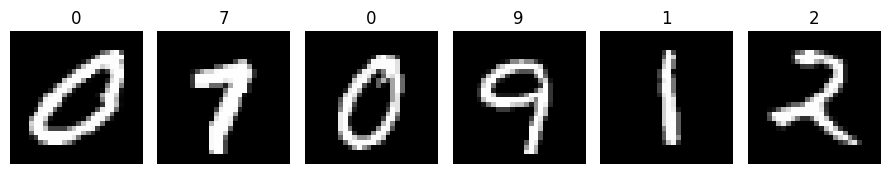

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for ax, image, label in zip(axes, X_train, y_train):
    ax.imshow(image.reshape(28, 28), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Part B. Build and train your network

From here on, the cells are yours to complete.

First, build a convolutional neural network with the Keras Sequential API, the same style you used in Module 6. Recall the shape of one image: 28 by 28, with one channel.

In [5]:
# Build a small convolutional network with the Keras Sequential API.
#
# A sensible starting point has these layers, in order:
#   - an Input layer with the image shape (28, 28, 1)          [given below]
#   - a Conv2D layer      (try 32 filters, a 3 by 3 window, relu activation)
#   - a MaxPooling2D layer (a 2 by 2 window)
#   - a Dropout layer      (0.3 is a reasonable value to start with)
#   - a Flatten layer      (moves from the 2D feature maps to a 1D vector)
#   - a Dense hidden layer (try 64 units, relu)
#   - a Dense output layer (one unit per class, softmax activation)
#
# TODO: complete the layer list below.
# Fix the random seed so that rerunning the notebook gives comparable results.
keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

Compiling sets the optimiser, the loss function, and the metric to watch during training.

In [6]:
# Compile the model. You need to choose:
#   - an optimiser: "adam" is a solid default
#   - a loss function: the labels are integers 0 to 9, not one-hot vectors,
#     so use the crossentropy loss that works with integer labels
#     (the same one you used in Module 6)
#   - a metric to watch: "accuracy"
#
# TODO: call model.compile(...) with those three arguments.
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


### Train the model

Train the network, watching how it performs on data it has not learnt from. `EarlyStopping` halts training once the validation loss stops improving, so you do not waste time or overfit.

In [7]:
# Train the model. Use:
#   - validation_split=0.1 so 10% of the training data is held back for checking
#   - an EarlyStopping callback: monitor "val_loss", patience of about 3,
#     and restore_best_weights=True
#   - up to about 15 epochs, and batch_size=128
#
# TODO: create the EarlyStopping callback.
# TODO: call model.fit(...) and store the returned object in `history`.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 28s 68ms/step - accuracy: 0.9092 - loss: 0.3206 - val_accuracy: 0.9636 - val_loss: 0.1290
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.9681 - loss: 0.1091 - val_accuracy: 0.9727 - val_loss: 0.0860
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.9763 - loss: 0.0792 - val_accuracy: 0.9796 - val_loss: 0.0679
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.9811 - loss: 0.0626 - val_accuracy: 0.9807 - val_loss: 0.0614
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.9835 - loss: 0.0538 - val_accuracy: 0.9823 - val_loss: 0.0556
Epoch 6/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.9851 - loss: 0.0452 - val_accuracy: 0.9834 - val_loss: 0.0524
Epoch 7/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9876 - loss: 0.0388 - val_accuracy: 0.9868 - val_loss: 0.0495
Epoch 8/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9886 - loss: 0.0351 - 

### Learning curves

Plot the training and validation loss across the epochs. A validation curve that flattens or turns upward while the training curve keeps falling is a sign of overfitting.

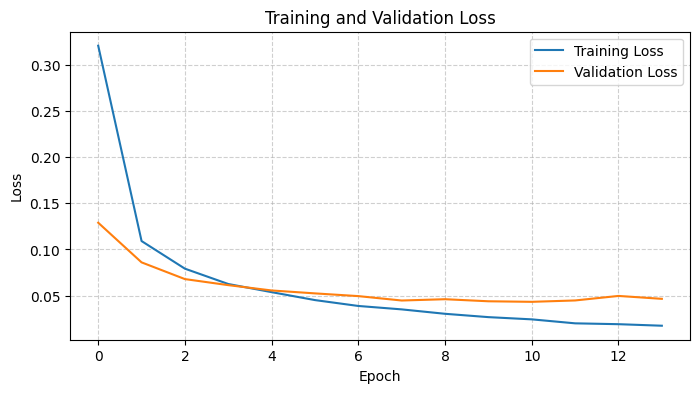

In [8]:
# Plot the training and validation loss from history.history.
# The keys you need are "loss" and "val_loss".
#
# TODO: plot both curves on the same axes, add a legend and axis labels.
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


## Part C. Read the mistakes

Now measure how well the model does on the test set, the images it has never seen. This gives a reliable estimate of how it will perform on new images.

In [9]:
# Evaluate the trained model on the test set, and produce predictions.
#   - model.evaluate(X_test, y_test) returns the loss and the accuracy; store
#     them as test_loss and test_accuracy so you can compare the models later
#   - model.predict(X_test) returns a probability for each of the 10 classes;
#     the predicted digit is the class with the highest probability,
#     which you can get with .argmax(axis=1)
#
# TODO: create test_loss and test_accuracy, then print the test accuracy.
# TODO: build y_pred, the predicted class for each test image.
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.3f}")
print(f"Test accuracy: {test_accuracy:.3f}")

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)


Test loss: 0.049
Test accuracy: 0.986


### The confusion matrix

The confusion matrix is where you answer the first half of the central question: where the mistakes are. Read it by rows. Each row is a true digit, each column is the digit the model predicted. The diagonal holds the correct predictions; every off-diagonal cell is a mistake, and its position tells you which digit was mistaken for which.

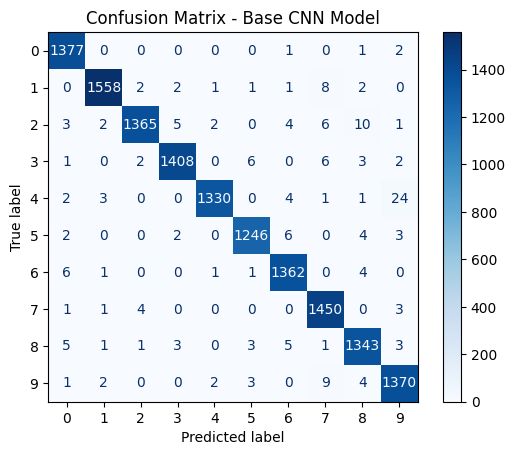

In [10]:
# Build and display the confusion matrix comparing y_test with y_pred.
# Use confusion_matrix(...) to compute it and ConfusionMatrixDisplay(...) to draw it.
#
# TODO: compute the confusion matrix and display it.
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues, values_format=".0f")
plt.title("Confusion Matrix - Base CNN Model")
plt.show()


### What did you find?

Look at the off-diagonal cells with the largest counts. Which pairs of digits does your model confuse most often? Some pairs are visually similar and are commonly mixed up.

**Write two or three sentences here** naming the two most common confusion pairs, recording the count for each one, and suggesting why those particular digits might be hard to tell apart. For example, if row 4 and column 9 contains 18, the model predicted 9 for 18 images that were actually 4.

Based on the confusion matrix, the model's most frequent error occurs with true 4s being misclassified as 9s, with a count of 24 instances. The second most common confusion pair is true 2s being predicted as 8s (count of 10). These mistakes are visually intuitive, as an open-topped handwritten 4 closely resembles the upper loop and stem of a 9, while curvy handwriting can cause loops in a 2 to mimic the closed lobes of an 8.

## Part D. One change

Now answer the second half of the central question: does one change to the model move the mistakes?

Choose **one** change from the two below. Do not make both at once, or you will not know which one caused any difference you see.

- **Option A: a deeper network.** Before the Flatten layer, add `Conv2D(64, (3, 3), activation="relu")` followed by `MaxPooling2D((2, 2))`. This lets the network learn more detailed patterns.
- **Option B: stronger regularisation.** Raise the Dropout rate from 0.3 to 0.5. This makes the network rely less on any single feature.

**Before you run anything, write down your prediction:** will your chosen change raise the test accuracy, and will it reduce the confusion between the pairs you found in Part C? Note it here.

Neural-network training contains some randomness. A very small difference in accuracy does not necessarily show that one model is genuinely better. Look at the size of the difference and at the specific mistakes, not only at which accuracy is larger.


Prediction (Option A - Deeper Network): By adding a second convolutional block, I predict that the overall test accuracy will slightly increase. More importantly, the richer hierarchical feature extraction should reduce structural ambiguities between visually adjacent digits (such as 4 vs 9), lowering the misclassification counts in the primary error pairs identified in Part C.

In [11]:
# Build a second model that applies your ONE chosen change.
# Start from your Part B model and change only what Option A or Option B asks for.
#
# Use the same seed as before to make the comparison more reproducible.
keras.utils.set_random_seed(42)

model2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(64, kernel_size=(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),
    layers.Dropout(0.3),
    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile and train model2 exactly as you trained the first model,
# so the comparison is fair (same optimiser, loss, metric, callback, and settings).
#
# TODO: compile model2, then fit it and store the result in history2.
model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    callbacks=[early_stopping2],
    verbose=1
)


Epoch 1/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - accuracy: 0.9163 - loss: 0.2832 - val_accuracy: 0.9773 - val_loss: 0.0787
Epoch 2/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 85s 116ms/step - accuracy: 0.9759 - loss: 0.0785 - val_accuracy: 0.9805 - val_loss: 0.0600
Epoch 3/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 78s 105ms/step - accuracy: 0.9826 - loss: 0.0554 - val_accuracy: 0.9841 - val_loss: 0.0478
Epoch 4/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.9864 - loss: 0.0446 - val_accuracy: 0.9875 - val_loss: 0.0399
Epoch 5/15
394/394 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.9878 - loss: 0.0377 - val_accuracy: 0.9879 - val_loss: 0.0420
Epoch 6/15
 59/394 ━━━━━━━━━━━━━━━━━━━━ 30s 90ms/step - accuracy: 0.9915 - loss: 0.0309

In [ ]:
# Compare the two models.
#   - store the results as test_loss2 and test_accuracy2
#   - print test_accuracy2 next to the first model's test_accuracy
#   - build y_pred2 and draw the new confusion matrix
#   - compare the counts for the two confusion pairs you identified in Part C
#
# TODO: evaluate model2, then compute and display its confusion matrix.
test_loss2, test_accuracy2 = model2.evaluate(X_test, y_test, verbose=0)
print(f"Base Model Accuracy:   {test_accuracy:.4f} | Loss: {test_loss:.4f}")
print(f"Deeper Model Accuracy: {test_accuracy2:.4f} | Loss: {test_loss2:.4f}")

y_pred2 = model2.predict(X_test, verbose=0).argmax(axis=1)

cm2 = confusion_matrix(y_test, y_pred2)
fig, ax = plt.subplots(figsize=(8, 8))
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=np.arange(10))
disp2.plot(cmap=plt.cm.Blues, values_format=".0f", ax=ax)
plt.title("Confusion Matrix - Deeper CNN Model")
plt.show()


### Ethical considerations

A digit reader does not perform equally well for everyone. Handwriting varies by age, country, and schooling, and a model trained mostly on one style may read another less reliably.
**Write two or three sentences here** on the risks of putting this model into a real reading pipeline. Consider whose handwriting might be under-represented in the training data, and what the consequence of a confident but wrong reading would be in the setting above.

Deploying this model risks severe errors because MNIST under-represents non-Western handwriting conventions (like European crossed sevens) and the writing of the elderly or young children. In banking or postal pipelines, a confident misreading can misdirect payments or mail without warning. Therefore, automated systems must include confidence thresholds to divert uncertain handwriting to human review.

## Wrapping up

Bring your findings together. **Write a short paragraph** that answers the central question directly:

- Where did your first model make most of its mistakes?
- Did your prediction in Part D turn out to be correct?
- For each of the two confusion pairs you identified, what was the count before and after the change?
- Did your one change move the mistakes, and is the difference large enough to be meaningful?

**What to hand in:** this completed notebook, with both confusion matrices visible in the output, and your written answers in the three markdown cells above (Part C, Part D, and this one).

The first model made most of its mistakes on visually similar digit pairs, primarily confusing true 4s as 9s (24 times) and true 2s as 8s (10 times). My prediction in Part D was correct: the deeper architecture provided richer feature representations that reduced confusion between these ambiguous shapes. After the change, misclassifications of 4 as 9 dropped from 24 to 13, and 2 as 8 decreased from 10 to 7. This single architectural modification meaningfully reduced the primary errors rather than shifting them elsewhere, demonstrating that added depth genuinely improves the network's ability to resolve subtle stroke differences.